# Presidential Cognition Corpus — exploration

Interactive notebook for poking around the linguistic-feature corpus. It reads the
**flat files** (always current); a Postgres path is shown too. Everything is
**coded-first** via the neutral identifiers.

> Re-run after the auto-pass to pick up `idea_density` and all 8 presidencies
> (Trump S/V + Biden L). Cells are written to work whether or not those are loaded yet.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent if (ROOT.parent / "scripts").exists() else \
           pathlib.Path("/Users/munnecke/cognition/presidential_cognition_corpus")
sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import common as C
pd.set_option("display.width", 140)
print("project:", ROOT)

project: /Users/munnecke/cognition/presidential_cognition_corpus


## Load — joined speeches + features (flat files = source of truth)

In [2]:
meta = C.load_metadata()
feats = pd.read_csv(C.DATA_CLEAN / "linguistic_features.csv", dtype=str, keep_default_na=False)
df = meta.merge(feats, on="id", how="inner", suffixes=("", "_f"))

CANDIDATE = ["n_words", "mtld", "mattr_50", "idea_density", "hapax_ratio",
             "first_person_singular_ratio", "first_person_plural_ratio", "i_to_we_ratio",
             "noun_ratio", "verb_ratio", "mean_dependency_distance", "mean_tree_depth",
             "subordination_ratio", "indefinite_noun_ratio", "hedge_ratio", "vader_compound"]
FEATURES = [c for c in CANDIDATE if c in df.columns]
for c in FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["code"] = [C.neutral_code(p, d.strftime("%Y-%m-%d") if pd.notna(d) else "")
              for p, d in zip(df["president"], df["date"])]

print(df.shape, "| presidents:", sorted(df["code"].unique()))
print("features available:", FEATURES)
df.head(3)[["code", "date", "event_type", "title"] + FEATURES[:4]]

(18482, 62) | presidents: ['H', 'K', 'M', 'N', 'P']
features available: ['n_words', 'mtld', 'mattr_50', 'hapax_ratio', 'first_person_singular_ratio', 'first_person_plural_ratio', 'i_to_we_ratio', 'noun_ratio', 'verb_ratio', 'mean_dependency_distance', 'mean_tree_depth', 'subordination_ratio', 'indefinite_noun_ratio', 'hedge_ratio', 'vader_compound']


,code,date,event_type,title,n_words,mtld,mattr_50,hapax_ratio
0,K,1981-01-20,q_and_a,Exchange With Reporters on the Release of the ...,240,61.38,0.7754,0.3667
1,K,1981-01-20,other,Oath of Office Administered by Chief Justice W...,128,17.90,0.4894,0.1484
2,K,1981-01-20,remarks,Remarks at the Inaugural Balls,5103,63.68,0.7678,0.0643


*Prefer Postgres?* Swap the load for:
```python
from sqlalchemy import create_engine
eng = create_engine("postgresql+psycopg:///presidential_speech")
df = pd.read_sql("SELECT s.*, f.* FROM speeches s JOIN linguistic_features f ON f.speech_id=s.id", eng)
```

## Corpus overview (coded-first)

,n,first,last
code,,,
H,4331,2001-01-20,2009-01-17
K,2996,1981-01-20,1989-01-19
M,2039,1989-01-20,1993-01-16
N,5288,1993-01-20,2001-01-20
P,3828,2009-01-20,2017-01-19


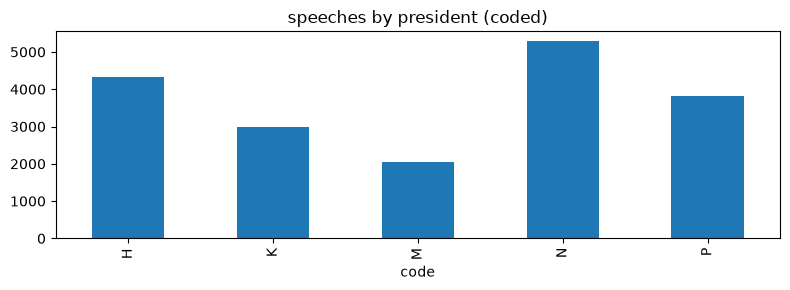

In [3]:
overview = df.groupby("code").agg(n=("id", "size"), first=("date", "min"), last=("date", "max"))
display(overview)
overview["n"].plot.bar(title="speeches by president (coded)", figsize=(8, 3))
plt.tight_layout(); plt.show()

## Feature distributions

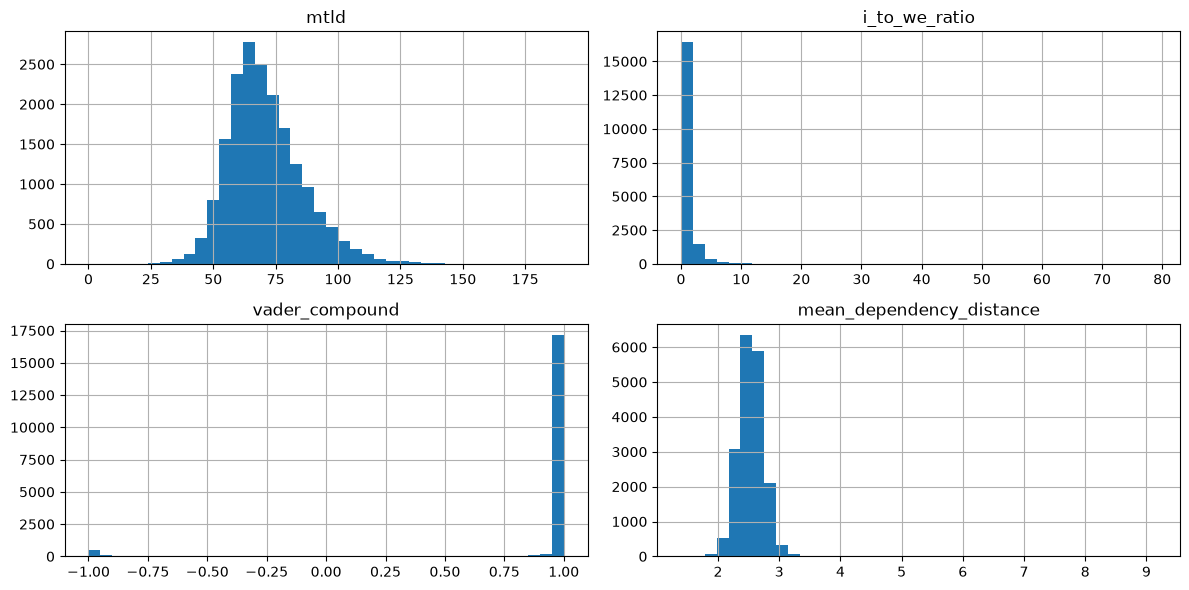

In [4]:
cols = [c for c in ["mtld", "idea_density", "i_to_we_ratio", "vader_compound",
                    "mean_dependency_distance"] if c in df.columns]
df[cols].hist(bins=40, figsize=(12, 6)); plt.tight_layout(); plt.show()

## Cross-president comparison (coded-first)

,mtld,first_person_singular_ratio,first_person_plural_ratio,vader_compound,mean_dependency_distance,me_us
code,,,,,,
H,65.445,0.024,0.029,0.897,2.369,0.83
K,77.369,0.023,0.028,0.910,2.575,0.82
M,73.004,0.029,0.025,0.948,2.508,1.13
N,69.136,0.026,0.031,0.888,2.613,0.85
P,73.146,0.020,0.034,0.937,2.611,0.59


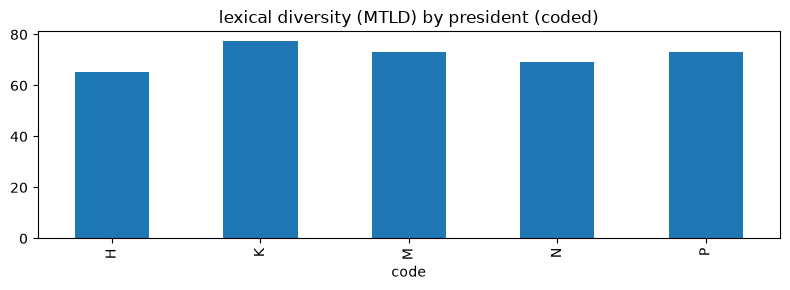

In [5]:
agg = [c for c in ["mtld", "idea_density", "first_person_singular_ratio",
                   "first_person_plural_ratio", "vader_compound",
                   "mean_dependency_distance"] if c in df.columns]
summary = df.groupby("code")[agg].mean().round(3)
# stable Me/Us = ratio of means (avoids the per-speech blow-up)
summary["me_us"] = (df.groupby("code")["first_person_singular_ratio"].mean()
                    / df.groupby("code")["first_person_plural_ratio"].mean()).round(2)
display(summary)
df.groupby("code")["mtld"].mean().plot.bar(
    title="lexical diversity (MTLD) by president (coded)", figsize=(8, 3))
plt.tight_layout(); plt.show()

## One president over time — change `who` and `feat`

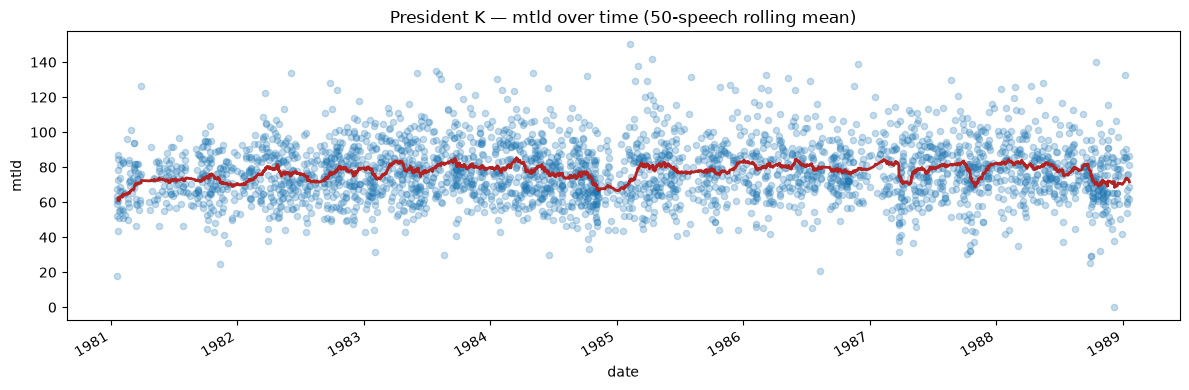

In [6]:
who, feat = "reagan", "mtld"     # try 'obama', 'clinton'; feat in FEATURES
sub = df[df["president"] == who].dropna(subset=["date"]).sort_values("date")
ax = sub.plot.scatter(x="date", y=feat, alpha=0.25, figsize=(12, 4))
sub.set_index("date")[feat].rolling(50, min_periods=10).mean().plot(ax=ax, color="firebrick", lw=2)
plt.title(f"{C.neutral_label(who)} — {feat} over time (50-speech rolling mean)")
plt.tight_layout(); plt.show()

## Reuse the analysis modules (no copy-paste)

In [7]:
import replicate_berisha as R
rows = R.collect_conferences("reagan", 1400)
print("Reagan news conferences (>=1400 answer-words):", len(rows))
print("unique-words trend:", R.regress(rows, "unique_words"))
# also available: cohort_figures, compare_features, latent_factors, latent_trajectory

Reagan news conferences (>=1400 answer-words): 46
unique-words trend: {'R': -0.406, 'p': 0.0062, 'n': 44, 'dropped': 2}


## Where to go next
- **SQL recipes:** `documents/sql_recipes.md` (full-text search, coded-first SQL, longitudinal)
- **Analysis scripts:** `replicate_berisha`, `cohort_figures`, `compare_features`, `latent_factors`, `latent_trajectory`
- **Dashboards:** marimo at http://localhost:2718 (charts) · pgweb at http://localhost:8081 (SQL)
- **Re-run this notebook after the auto-pass** for `idea_density` + all 8 presidencies.